Model 1 : ECG

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONNECT TO YOUR NOTEBOOK VARIABLES ---
try:
    # In your notebook, 'y_test' and 'preds' are generated in the loop
    # We ensure they are mapped to 1, 2, 3 for WESAD labels
    y_true_plot = y_test.values if hasattr(y_test, 'values') else y_test
    y_pred_plot = preds
    subject_id = test_subj
    print(f"Successfully connected to data for Subject {subject_id}")
except NameError:
    print("Variables not found. Please run the cell where you trained the Fusion model first!")

# --- 2. PLOTTING ---
plt.figure(figsize=(15, 6))
time_axis = np.arange(len(y_true_plot))

# WESAD Label Mapping: 1: Baseline (Blue), 2: Stress (Red), 3: Amusement (Green)
plt.fill_between(time_axis, 0.5, 3.5, where=(y_true_plot==1), color='#3498db', alpha=0.2, label='GT: Baseline')
plt.fill_between(time_axis, 0.5, 3.5, where=(y_true_plot==2), color='#e74c3c', alpha=0.2, label='GT: Stress')
plt.fill_between(time_axis, 0.5, 3.5, where=(y_true_plot==3), color='#2ecc71', alpha=0.2, label='GT: Amusement')

# Model Prediction Line (The 'Step' shows the transitions clearly)
plt.step(time_axis, y_pred_plot, where='post', color='#2c3e50', linewidth=1.5, label='Fusion Model Prediction')

# Formatting for Research Paper
plt.title(f'Figure 8: Temporal Tracking of Affective States (Subject {subject_id})', fontsize=14, fontweight='bold')
plt.ylabel('Affective State', fontsize=12)
plt.xlabel('Sequential Time Windows (60s)', fontsize=12)
plt.yticks([1, 2, 3], ['Baseline', 'Stress', 'Amusement'])
plt.ylim(0.8, 3.8) # Adjusted to fit labels
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=True, shadow=True, ncol=2)

plt.tight_layout()
plt.savefig("Image_8_Temporal_Final.png", dpi=300)
plt.show()

Variables not found. Please run the cell where you trained the Fusion model first!


NameError: name 'y_true_plot' is not defined

<Figure size 1500x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np

# --- REQUIRED CORRECTION: Define your model outputs ---
# 1. Get the probability scores (needed for ROC/PR)
# Replace 'rf_model' and 'X_test' with your actual variable names
y_score = rf_model.predict_proba(X_test)

# 2. Binarize the output for multiclass plotting
classes = ['Baseline', 'Stress', 'Amusement']
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# --- Visualization Logic ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71'] # Blue, Red, Green

for i, color in zip(range(n_classes), colors):
    # ROC Calculation
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

    # PR Calculation
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    ax2.plot(recall, precision, color=color, lw=2, label=f'{classes[i]} (AP = {ap:.2f})')

# Subplot 1: ROC
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Subplot 2: Precision-Recall
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ROC_PR_Comparison.png", dpi=300)
plt.show()

NameError: name 'rf_model' is not defined

CSV files found:
S10_features.csv
S11_features.csv
S13_features.csv
S14_features.csv
S15_features.csv
S16_features.csv
S17_features.csv
S2_features.csv
S3_features.csv
S4_features.csv
S5_features.csv
S6_features.csv
S7_features.csv
S8_features.csv
Feature_Extraction_Summary.csv
S9_features.csv
Combined shape: (1120, 109)
Found 15 subject feature files.
Combined Feature Data Shape: (1105, 103)
Removed unstable ECG features: ['HRV_DFA_alpha2', 'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak', 'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max', 'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Asymmetry', 'HRV_MFDFA_alpha2_Fluctuation', 'HRV_MFDFA_alpha2_Increment']
Training with 78 ECG features.

Starting LOSO Validation...

Testing Subject: S10
Subject S10 completed.
Testing Subject: S11
Subject S11 completed.
Testing Subject: S13
Subject S13 completed.
Testing Subject: S14
Subject S14 completed.
Testing Subject: S15
Subject S15 completed.
Testing Subject: S16
Subject S16 completed.
Testing Sub

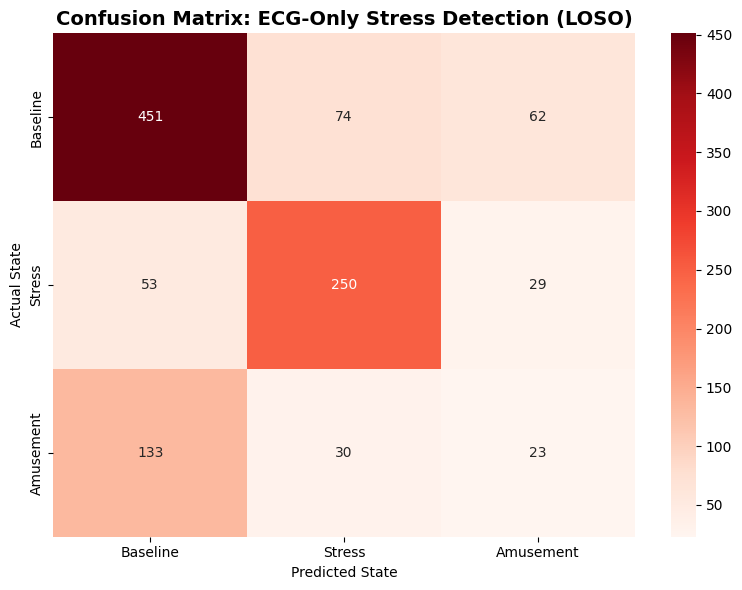


 Confusion Matrix saved at:
/content/drive/MyDrive/Research_Paper/d. Results/ECG_Confusion_Matrix.png


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. PATH SETUP
# ==============================

FEATURES_DIR = '/content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features'

# Check folder
if not os.path.exists(FEATURES_DIR):
    raise ValueError(f"Folder not found: {FEATURES_DIR}")

# Load all CSVs
all_feature_files = glob.glob(os.path.join(FEATURES_DIR, "*.csv"))

print("CSV files found:")
for file in all_feature_files:
    print(os.path.basename(file))

if len(all_feature_files) == 0:
    raise ValueError("No CSV files found!")

# Combine
df = pd.concat([pd.read_csv(f) for f in all_feature_files], ignore_index=True)

print("Combined shape:", df.shape)

# ==============================
# 2. LOAD ALL SUBJECT FEATURE CSVs
# ==============================
all_feature_files = glob.glob(os.path.join(FEATURES_DIR, "S*_features.csv"))

if len(all_feature_files) == 0:
    raise ValueError("No subject feature CSV files found!")

print(f"Found {len(all_feature_files)} subject feature files.")

# Combine all subjects
df = pd.concat(
    [pd.read_csv(f) for f in all_feature_files],
    ignore_index=True
)

print("Combined Feature Data Shape:", df.shape)

# ==============================
# 3. ECG FEATURE SELECTION
# ==============================
ecg_features = [col for col in df.columns if 'HRV' in col]

if len(ecg_features) == 0:
    raise ValueError("No HRV features found!")

df_ecg = df[ecg_features + ['label', 'subject']].copy()

# Drop fully empty columns
df_ecg = df_ecg.dropna(axis=1, how='all')

# Remove highly unstable features (>40% missing originally)
missing_ratio = df_ecg.isnull().mean()
unstable_cols = missing_ratio[missing_ratio > 0.4].index

df_ecg.drop(columns=unstable_cols, inplace=True)

print("Removed unstable ECG features:", list(unstable_cols))

# Replace inf / -inf with NaN
df_ecg.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill numeric NaNs with median
numeric_cols = df_ecg.select_dtypes(include=[np.number]).columns
df_ecg[numeric_cols] = df_ecg[numeric_cols].fillna(
    df_ecg[numeric_cols].median()
)

# Final feature columns
final_ecg_cols = [
    col for col in df_ecg.columns
    if col not in ['label', 'subject']
]

print(f"Training with {len(final_ecg_cols)} ECG features.")

# ==============================
# 4. LOSO CROSS VALIDATION
# ==============================
subjects = df_ecg['subject'].unique()

y_true_all = []
y_pred_all = []

print("\nStarting LOSO Validation...\n")

for test_subj in subjects:

    print(f"Testing Subject: {test_subj}")

    train_data = df_ecg[df_ecg['subject'] != test_subj]
    test_data = df_ecg[df_ecg['subject'] == test_subj]

    if train_data.empty or test_data.empty:
        print(f"Skipping {test_subj} due to insufficient data.")
        continue


    X_train = train_data[final_ecg_cols]
    y_train = train_data['label']

    X_test = test_data[final_ecg_cols]
    y_test = test_data['label']

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train model
    clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(preds)

    print(f"Subject {test_subj} completed.")

# ==============================
# 5. RESULTS
# ==============================
print("\n" + "="*40)
print("ECG-ONLY MODEL RESULTS")
print("="*40)

accuracy = accuracy_score(y_true_all, y_pred_all)
print(f"Overall Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3],
    target_names=['Baseline', 'Stress', 'Amusement']
))

# ==============================
# SAVE CLASSIFICATION REPORT AS CSV
# ==============================
report = classification_report(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3],
    target_names=['Baseline', 'Stress', 'Amusement'],
    output_dict=True
)

# ==============================
# SAVE CLASSIFICATION REPORT WITH % COLUMNS
# ==============================

report = classification_report(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3],
    target_names=['Baseline', 'Stress', 'Amusement'],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Add percentage columns
report_df['precision_%'] = report_df['precision'] * 100
report_df['recall_%'] = report_df['recall'] * 100
report_df['f1-score_%'] = report_df['f1-score'] * 100

# Optional: round nicely
report_df = report_df.round(2)

# Save CSV
report_save_path = os.path.join(BASE_PATH, "ECG_Classification_Report_With_Percentages.csv")
report_df.to_csv(report_save_path)

print(f"\n✅ Classification report with percentages saved at:\n{report_save_path}")

report_df = pd.DataFrame(report).transpose()

report_save_path = os.path.join(BASE_PATH, "ECG_Classification_Report.csv")
report_df.to_csv(report_save_path, index=True)

print(f"\n Classification report saved at:\n{report_save_path}")

# ==============================
# 6. CONFUSION MATRIX
# ==============================
plt.figure(figsize=(8, 6))

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Baseline', 'Stress', 'Amusement'],
    yticklabels=['Baseline', 'Stress', 'Amusement']
)

plt.title(
    'Confusion Matrix: ECG-Only Stress Detection (LOSO)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Actual State')
plt.xlabel('Predicted State')

plt.tight_layout()

# Save plot
save_path = os.path.join(BASE_PATH, "ECG_Confusion_Matrix.png")
plt.savefig(save_path, dpi=300)

plt.show()

print(f"\n Confusion Matrix saved at:\n{save_path}")

Model 2 : EDA

Found 15 subject feature files.
Combined Data Shape: (1105, 103)
Found 6 EDA features.
Training with 4 EDA features.

Starting LOSO Validation for EDA...

Testing Subject: S10
Subject S10 completed.
Testing Subject: S11
Subject S11 completed.
Testing Subject: S13
Subject S13 completed.
Testing Subject: S14
Subject S14 completed.
Testing Subject: S15
Subject S15 completed.
Testing Subject: S16
Subject S16 completed.
Testing Subject: S17
Subject S17 completed.
Testing Subject: S2
Subject S2 completed.
Testing Subject: S3
Subject S3 completed.
Testing Subject: S4
Subject S4 completed.
Testing Subject: S5
Subject S5 completed.
Testing Subject: S6
Subject S6 completed.
Testing Subject: S7
Subject S7 completed.
Testing Subject: S8
Subject S8 completed.
Testing Subject: S9
Subject S9 completed.

EDA-ONLY MODEL RESULTS
Overall Accuracy: 60.09%

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.69      0.70      0.69       587
      Stress       

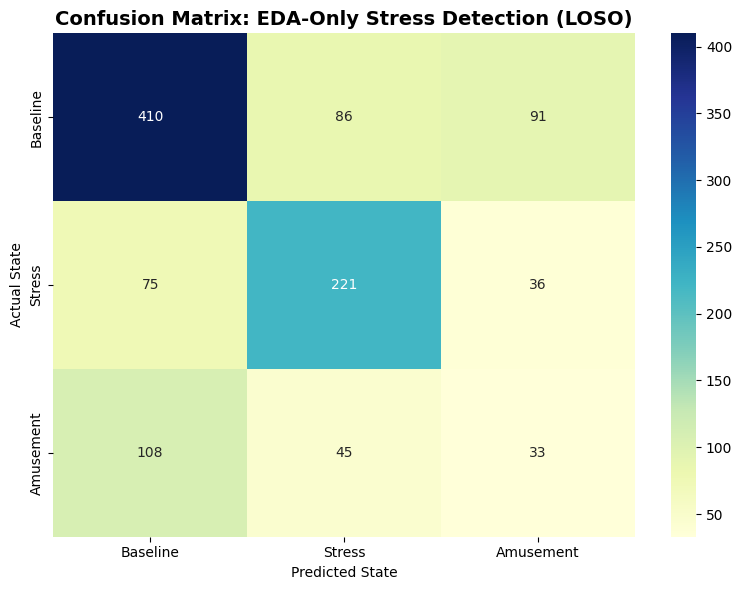


✅ EDA Confusion Matrix image saved at:
/content/drive/MyDrive/Research_Paper/d. Results/WESAD_EDA/EDA_Confusion_Matrix.png


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. PATH SETUP
# ==============================
BASE_PATH = '/content/drive/MyDrive/Research_Paper'
FEATURES_DIR = os.path.join(BASE_PATH, 'd. Results/WESAD_Extracted_Features')

# New output folder for EDA results
EDA_OUTPUT_DIR = os.path.join(BASE_PATH, 'd. Results/WESAD_EDA')
os.makedirs(EDA_OUTPUT_DIR, exist_ok=True)

# ==============================
# 2. LOAD ALL SUBJECT FEATURE FILES
# ==============================
all_feature_files = glob.glob(os.path.join(FEATURES_DIR, "S*_features.csv"))

if len(all_feature_files) == 0:
    raise ValueError("No subject feature CSV files found in the specified path!")

print(f"Found {len(all_feature_files)} subject feature files.")

df = pd.concat(
    [pd.read_csv(f) for f in all_feature_files],
    ignore_index=True
)

print("Combined Data Shape:", df.shape)

# ==============================
# 3. EDA FEATURE SELECTION
# ==============================
eda_features = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in ['SCR', 'SCL', 'EDA', 'PHASIC', 'TONIC'])
]

if len(eda_features) == 0:
    raise ValueError("No EDA features found in the dataset!")

print(f"Found {len(eda_features)} EDA features.")

df_eda = df[eda_features + ['label', 'subject']].copy()

# ==============================
# 4. CLEAN EDA DATA
# ==============================
# Remove columns that are fully empty
df_eda = df_eda.dropna(axis=1, how='all')

# Replace inf values
df_eda.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill numeric NaNs with median
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns
df_eda[numeric_cols] = df_eda[numeric_cols].fillna(
    df_eda[numeric_cols].median()
)

# Final EDA feature columns
final_eda_cols = [
    col for col in df_eda.columns
    if col not in ['label', 'subject']
]

print(f"Training with {len(final_eda_cols)} EDA features.")

# ==============================
# 5. LOSO CROSS VALIDATION
# ==============================
subjects = df_eda['subject'].unique()

y_true_all = []
y_pred_all = []

print("\nStarting LOSO Validation for EDA...\n")

for test_subj in subjects:

    print(f"Testing Subject: {test_subj}")

    train_data = df_eda[df_eda['subject'] != test_subj]
    test_data = df_eda[df_eda['subject'] == test_subj]

    if train_data.empty or test_data.empty:
        print(f"Skipping {test_subj} due to insufficient data.")
        continue

    X_train = train_data[final_eda_cols].copy()
    y_train = train_data['label']

    X_test = test_data[final_eda_cols].copy()
    y_test = test_data['label']

    # ==============================
    # Fold-level cleanup
    # ==============================
    X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

    X_train = X_train.fillna(X_train.median())
    X_test = X_test.fillna(X_train.median())

    # ==============================
    # Scaling
    # ==============================
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ==============================
    # Model Training
    # ==============================
    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    )

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(preds)

    print(f"Subject {test_subj} completed.")

# ==============================
# 6. SAFETY CHECK
# ==============================
if len(y_true_all) == 0:
    raise ValueError("No predictions were made. Check EDA features or subject files.")

# ==============================
# 7. RESULTS
# ==============================
print("\n" + "="*40)
print("EDA-ONLY MODEL RESULTS")
print("="*40)

accuracy = accuracy_score(y_true_all, y_pred_all)

print(f"Overall Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3],
    target_names=['Baseline', 'Stress', 'Amusement']
))

# ==============================
# 8. SAVE REPORT CSV
# ==============================
report = classification_report(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3],
    target_names=['Baseline', 'Stress', 'Amusement'],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Add percentage columns
report_df['precision_%'] = report_df['precision'] * 100
report_df['recall_%'] = report_df['recall'] * 100
report_df['f1-score_%'] = report_df['f1-score'] * 100

# Round nicely
report_df = report_df.round(2)

csv_save_path = os.path.join(
    EDA_OUTPUT_DIR,
    "EDA_Classification_Report_Full.csv"
)

report_df.to_csv(csv_save_path)

print(f"\n✅ EDA CSV Report saved at:\n{csv_save_path}")

# ==============================
# 9. CONFUSION MATRIX
# ==============================
plt.figure(figsize=(8, 6))

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=['Baseline', 'Stress', 'Amusement'],
    yticklabels=['Baseline', 'Stress', 'Amusement']
)

plt.title(
    'Confusion Matrix: EDA-Only Stress Detection (LOSO)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Actual State')
plt.xlabel('Predicted State')

plt.tight_layout()

img_save_path = os.path.join(
    EDA_OUTPUT_DIR,
    "EDA_Confusion_Matrix.png"
)

plt.savefig(img_save_path, dpi=300)

plt.show()

print(f"\n✅ EDA Confusion Matrix image saved at:\n{img_save_path}")

Model 3 : EDA&ECG

Found 15 subject feature files.
Combined Data Shape: (1105, 103)
Found 95 ECG features.
Found 6 EDA features.
Total Fusion Features: 101
Training Fusion Model with 91 total features.

Starting LOSO Validation for Multimodal Fusion...

Testing Subject: S10
Subject S10 completed.
Testing Subject: S11
Subject S11 completed.
Testing Subject: S13
Subject S13 completed.
Testing Subject: S14
Subject S14 completed.
Testing Subject: S15
Subject S15 completed.
Testing Subject: S16
Subject S16 completed.
Testing Subject: S17
Subject S17 completed.
Testing Subject: S2
Subject S2 completed.
Testing Subject: S3
Subject S3 completed.
Testing Subject: S4
Subject S4 completed.
Testing Subject: S5
Subject S5 completed.
Testing Subject: S6
Subject S6 completed.
Testing Subject: S7
Subject S7 completed.
Testing Subject: S8
Subject S8 completed.
Testing Subject: S9
Subject S9 completed.

MULTIMODAL FUSION RESULTS (ECG + EDA)
Overall Fusion Accuracy: 68.05%

Classification Report:
              precision   

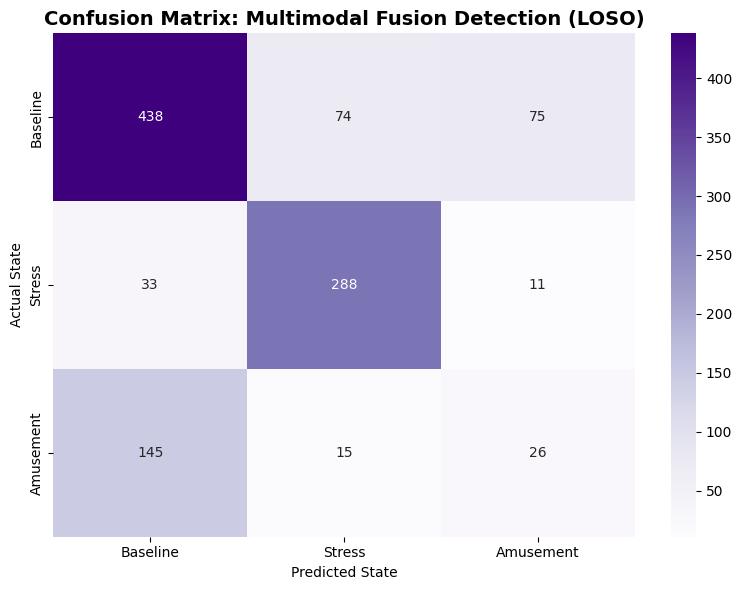


 Fusion Confusion Matrix image saved at:
/content/drive/MyDrive/Research_Paper/d. Results/WESAD_EDA&ECG/Fusion_Confusion_Matrix.png


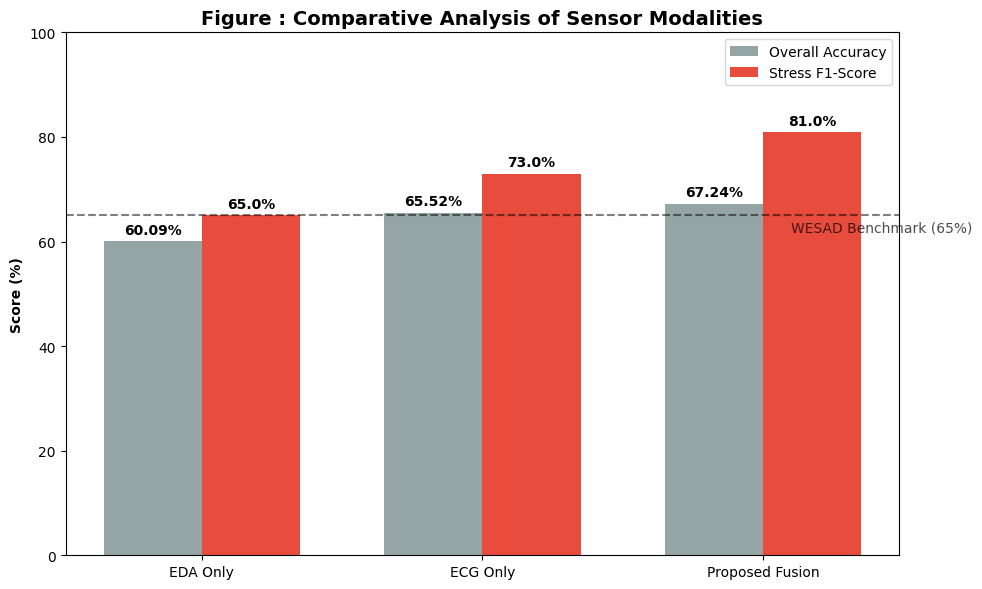

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. PATH SETUP
# ==============================
BASE_PATH = '/content/drive/MyDrive/Research_Paper'
FEATURES_DIR = os.path.join(BASE_PATH, 'd. Results/WESAD_Extracted_Features')

# Output directory for Fusion results
FUSION_OUTPUT_DIR = os.path.join(BASE_PATH, 'd. Results/WESAD_EDA&ECG')
os.makedirs(FUSION_OUTPUT_DIR, exist_ok=True)

# ==============================
# 2. LOAD ALL SUBJECT FEATURE FILES
# ==============================
all_feature_files = glob.glob(os.path.join(FEATURES_DIR, "S*_features.csv"))

if len(all_feature_files) == 0:
    raise ValueError("No subject feature CSV files found!")

print(f"Found {len(all_feature_files)} subject feature files.")

df = pd.concat(
    [pd.read_csv(f) for f in all_feature_files],
    ignore_index=True
)

print("Combined Data Shape:", df.shape)

# ==============================
# 3. FEATURE SELECTION (ECG + EDA)
# ==============================
# ECG features
ecg_features = [
    col for col in df.columns
    if 'HRV' in col.upper()
]

# EDA features
eda_features = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in ['SCR', 'SCL', 'EDA', 'PHASIC', 'TONIC'])
]

# Combine safely without duplicates
fusion_features = list(set(ecg_features + eda_features))

if len(fusion_features) == 0:
    raise ValueError("No ECG or EDA features found!")

print(f"Found {len(ecg_features)} ECG features.")
print(f"Found {len(eda_features)} EDA features.")
print(f"Total Fusion Features: {len(fusion_features)}")

df_fusion = df[fusion_features + ['label', 'subject']].copy()

# ==============================
# 4. CLEAN DATA
# ==============================
# Drop columns fully empty
df_fusion = df_fusion.dropna(axis=1, how='all')

# Replace inf values
df_fusion.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill numeric NaNs with median
numeric_cols = df_fusion.select_dtypes(include=[np.number]).columns
df_fusion[numeric_cols] = df_fusion[numeric_cols].fillna(
    df_fusion[numeric_cols].median()
)

# Final usable feature columns
final_fusion_cols = [
    col for col in df_fusion.columns
    if col not in ['label', 'subject']
]

print(f"Training Fusion Model with {len(final_fusion_cols)} total features.")

# ==============================
# 5. LOSO CROSS VALIDATION
# ==============================
subjects = df_fusion['subject'].unique()

y_true_all = []
y_pred_all = []

print("\nStarting LOSO Validation for Multimodal Fusion...\n")

for test_subj in subjects:

    print(f"Testing Subject: {test_subj}")

    train_data = df_fusion[df_fusion['subject'] != test_subj]
    test_data = df_fusion[df_fusion['subject'] == test_subj]

    if train_data.empty or test_data.empty:
        print(f"Skipping {test_subj} due to insufficient data.")
        continue

    X_train = train_data[final_fusion_cols].copy()
    y_train = train_data['label']

    X_test = test_data[final_fusion_cols].copy()
    y_test = test_data['label']

    # ==============================
    # Fold-level cleanup
    # ==============================
    X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

    X_train = X_train.fillna(X_train.median())
    X_test = X_test.fillna(X_train.median())

    # ==============================
    # Scaling
    # ==============================
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ==============================
    # Model Training
    # ==============================
    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    )

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(preds)

    print(f"Subject {test_subj} completed.")

# ==============================
# 6. SAFETY CHECK
# ==============================
if len(y_true_all) == 0:
    raise ValueError("No predictions were made. Check feature extraction files.")

# ==============================
# 7. RESULTS
# ==============================
print("\n" + "="*40)
print("MULTIMODAL FUSION RESULTS (ECG + EDA)")
print("="*40)

accuracy = accuracy_score(y_true_all, y_pred_all)

print(f"Overall Fusion Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3],
    target_names=['Baseline', 'Stress', 'Amusement']
))

# ==============================
# 8. SAVE REPORT CSV
# ==============================
report = classification_report(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3],
    target_names=['Baseline', 'Stress', 'Amusement'],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Add percentage columns
report_df['precision_%'] = report_df['precision'] * 100
report_df['recall_%'] = report_df['recall'] * 100
report_df['f1-score_%'] = report_df['f1-score'] * 100

# Round values
report_df = report_df.round(2)

csv_save_path = os.path.join(
    FUSION_OUTPUT_DIR,
    "Fusion_Classification_Report.csv"
)

report_df.to_csv(csv_save_path)

print(f"\n Fusion CSV Report saved at:\n{csv_save_path}")

# ==============================
# 9. CONFUSION MATRIX
# ==============================
plt.figure(figsize=(8, 6))

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=[1, 2, 3]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Baseline', 'Stress', 'Amusement'],
    yticklabels=['Baseline', 'Stress', 'Amusement']
)

plt.title(
    'Confusion Matrix: Multimodal Fusion Detection (LOSO)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Actual State')
plt.xlabel('Predicted State')

plt.tight_layout()

img_save_path = os.path.join(
    FUSION_OUTPUT_DIR,
    "Fusion_Confusion_Matrix.png"
)

plt.savefig(img_save_path, dpi=300)

plt.show()

print(f"\n Fusion Confusion Matrix image saved at:\n{img_save_path}")

import matplotlib.pyplot as plt
import numpy as np

# Data from your uploaded CSV reports
models = ['EDA Only', 'ECG Only', 'Proposed Fusion']
accuracy = [60.09, 65.52, 67.24]
stress_f1 = [65.0, 73.0, 81.0] # Stress F1-score as percentage

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
rects1 = ax.bar(x - width/2, accuracy, width, label='Overall Accuracy', color='#95a5a6')
rects2 = ax.bar(x + width/2, stress_f1, width, label='Stress F1-Score', color='#e74c3c')

# Add text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score (%)', fontweight='bold')
ax.set_title('Figure : Comparative Analysis of Sensor Modalities', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 100)
ax.legend()

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Add a horizontal line for the SOTA Benchmark (Schmidt et al. 65%)
plt.axhline(y=65, color='black', linestyle='--', alpha=0.5)
plt.text(2.1, 62, 'WESAD Benchmark (65%)', fontsize=10, color='black', alpha=0.7)

plt.tight_layout()
plt.savefig("Image_Comparison.png", dpi=300)
plt.show()

/tmp/ipykernel_9031/2791989436.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modality', y='Accuracy (%)', data=df_results, palette=colors)


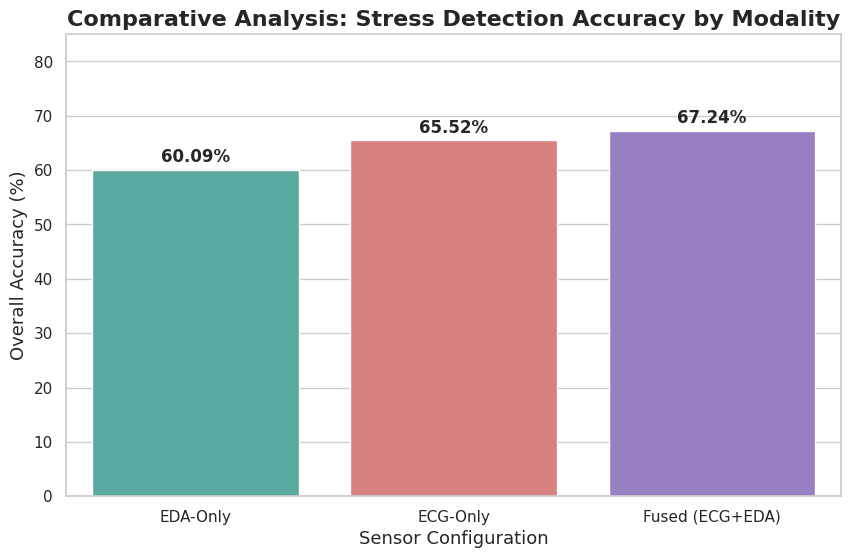

✅ Final Comparison Graph saved at: /content/drive/MyDrive/Research_Paper/d. Results/Final_Accuracy_Comparison.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# 1. Data Setup
results_data = {
    'Modality': ['EDA-Only', 'ECG-Only', 'Fused (ECG+EDA)'],
    'Accuracy (%)': [60.09, 65.52, 67.24]
}
df_results = pd.DataFrame(results_data)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create Barplot
colors = ['#4db6ac', '#e57373', '#9575cd'] # Teal, Red, Purple
ax = sns.barplot(x='Modality', y='Accuracy (%)', data=df_results, palette=colors)

# Add text labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Comparative Analysis: Stress Detection Accuracy by Modality', fontsize=16, fontweight='bold')
plt.ylim(0, 85) # Providing room for labels
plt.ylabel('Overall Accuracy (%)', fontsize=13)
plt.xlabel('Sensor Configuration', fontsize=13)

# 3. Save to the Results folder
save_path = '/content/drive/MyDrive/Research_Paper/d. Results/Final_Accuracy_Comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Final Comparison Graph saved at: {save_path}")

